# NB1 : Generating Keys and Data Cleaning

**Purpose**: To perform the initial data cleaning on the raw data set pulled using [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scraping software.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: Creating Keys To Link Databases

###  Importing raw data files

Data frame descriptions:

`query_df`: This data frame contains the meta data for each of the sampled Google Scholar profiles.

`papers_df`: This data frame containing *all* the citation entries for each the first 1000 papers pulled from the Google Scholar profiles. The features in this column are:

   - `Cites`: The number of citations the paper has received.
   - `Authors`: The names of the authors (Not all included)
   - `Title`: The title of the entry 
   - `Source`: The title of the journal where the entry is published.
   - `Year`: The Year of entry's publication.
   - `CitesURL`: URL to cite the paper.

In [2]:
query_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\author_PoPMetrics_V2.2.csv")
papers_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\results_PoPCites_V2.2.csv",low_memory = True)

In [3]:
query_df.head(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,g_coverage,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA
0,0,Edward Sargent - University of Toronto,Google Scholar Profile,1000,119190,27,4414.44,119.19,22989.19,225.13,...,88.1,383,1996,2023,119190,751,665,517,247,69
1,1,Norbert Koch - Institut für Physik &IRIS Adler...,Google Scholar Profile,560,26197,26,1007.58,46.78,5580.69,106.68,...,83.4,76,1997,2023,26197,337,285,166,30,24
2,2,"Dieter Neher - University of Potsdam, Institut...",Google Scholar Profile,559,36923,87,424.40,66.05,7764.41,115.04,...,86.3,122,1936,2023,36923,329,274,183,65,31


In [4]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,Publisher,ArticleURL,CitesURL,GSRank,QueryDate,...,StartPage,EndPage,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,Age,Abstract,FullTextURL,RelatedURL
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,...,519.0,522.0,4186,523.25,523,8,8.0,NaN,NaN,NaN
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,...,245.0,248.0,2319,463.80,258,9,5.0,NaN,NaN,NaN
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,...,138.0,142.0,2163,120.17,309,7,18.0,NaN,NaN,NaN


### Creating Foreign Keys 

**Goal**: Create foreign keys to link entries in `papers_id` with their Google Scholar profile in `query_df`

**Method**: We will create a new column in `papers_id` called `query_id` which will hold a foreign key to link the entires in the `papers_df` with their respective Google scholar profiles in `query_df`. This will be used to join the `papers_df` and `query_df` with `query_id` and `id` respectively. Since the web scrapper sorted the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `query_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `query_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | query_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [5]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = query_df.shape

# Assign query_ids
query_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    query_id[start:stop] = i

# Save query series to df
quer_ser = pd.Series(query_id)
papers_df['query_id'] = quer_ser

We see that the `papers_df` has a new column `query_id`

In [6]:
papers_df['query_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: query_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


In [7]:
papers_df['query_id'].value_counts()

0.0      1000
1.0       560
2.0       559
3.0       503
4.0       414
         ... 
611.0       2
612.0       2
613.0       2
614.0       2
615.0       2
Name: query_id, Length: 616, dtype: int64

We can check if all the entires in the `query_df` are accounted for in the `query_id` column by checking if the unique values in the `query_id` column equals the number of entries in the `query_df`.

In [8]:
papers_df['query_id'].value_counts().count() == query_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `query_id` column was successful! Let's save the resulting `papers_df` into `pickle`.

In [9]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part1.pkl")

### Conclusion

We now have a foreign key to join the entires in `papers_df` to `query_df`. This will be helpful when needing to access information only available in the from the `query_df` for each entry.

## Part 2: Addressing Null Values in `papers_df`

**Goal**: We want to remove null values from the `papers_df` while still preserving as much information as possible for ranking *publication* entries. Therefore, we will prioritize *not* deleting columns that store information about the citation that could determine its publication rank such as...
- `Source`
- `Type`
-  `Authors`
- `Citations`
- `GSRank`
- `ECC`

...and instead investigate if it is possible to either mass source the null information (by pulling the information from another column, for example) or determine if the entry is not relevant to creating a data base of publications (for example, if the entry is of a non-publication citation like a poster, workshop, lecture, data base entry, etc.).

Let's access the fraction of null values in `papers_df`for each column

In [10]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Abstract          1.000000
Age               0.037547
ArticleURL        1.000000
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
DOI               1.000000
ECC               0.000000
EndPage           0.259968
FullTextURL       1.000000
GSRank            0.000000
ISSN              1.000000
Issue             0.429692
Publisher         0.993499
QueryDate         0.000000
RelatedURL        1.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

Let's drop the columns were over 99% of the entires are null values.

In [11]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher'], axis = 1)

In [12]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,CitesURL,GSRank,QueryDate,Type,CitationURL,Volume,Issue,StartPage,EndPage,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,Age,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,347.0,6221.0,519.0,522.0,4186,523.25,523,8,8.0,0.0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,562.0,7726.0,245.0,248.0,2319,463.80,258,9,5.0,0.0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,4.0,2.0,138.0,142.0,2163,120.17,309,7,18.0,0.0


Let's look at the sources of remaining null values.

In [13]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Age               0.037547
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
ECC               0.000000
EndPage           0.259968
GSRank            0.000000
Issue             0.429692
QueryDate         0.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

We can remove columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry. The citation entries can be found using the authors, article title and source so these columns are not needed. We can also drop `Age` since we can determine the age of the citation from the year it was published.

In [14]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

We can also remove the columns `CitesURL`, `QueryDate` and `CitationURL` since they don't contain useful data for our model.

In [15]:
papers_df = papers_df.drop(['CitesURL', 'QueryDate', 'CitationURL'], axis = 1)

Let's look at the remaining null values.

In [16]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

AuthorCount       0.000000
Authors           0.000596
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
ECC               0.000000
GSRank            0.000000
Source            0.062569
Title             0.000000
Type              0.116042
Year              0.037547
query_id          0.000000
dtype: float64

Let's investigate the where the null values for the `Authors` column are.

In [17]:
papers_df[papers_df['Authors'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
26613,0,NaN,Heterogeneous self-supported dirhodium (ii) ca...,NaN,NaN,38,NaN,0,0.0,0,0,226.0
17690,0,NaN,Development of Geopolymers for Catalyst Suppor...,NaN,"MATERIALS RESEARCH,",89,NaN,0,0.0,0,0,78.0
17644,0,NaN,Outstanding dispersion of CeO2 on reduced grap...,2020.0,DIAMOND AND RELATED MATERIALS,43,Journal article,0,0.0,0,0,78.0
17598,0,NaN,Development of Geopolymers for Catalyst Suppor...,NaN,"MATERIALS RESEARCH,",89,NaN,0,0.0,0,0,77.0
17552,0,NaN,Outstanding dispersion of CeO2 on reduced grap...,2020.0,DIAMOND AND RELATED MATERIALS,43,Journal article,0,0.0,0,0,77.0


The `Author` column still has a few null values, though the number of entires drop from representing 0.596% of the data to 0.350% of the data. Let's go a head and drop those entires.

In [18]:
papers_df = papers_df.dropna(subset = 'Authors')

In [19]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Type              0.115843
Source            0.062457
Year              0.037361
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's investigate the entires that have a null value in their `Type` column.

In [20]:
papers_df[papers_df['Type'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
6815,12,"P Olmos, JM Perez, G Garcia-Belmonte, A Bru, J...",Computer simulations of the behaviour of the p...,1991.0,Nuclear Instruments and Methods in Physics Res...,180,NaN,12,0.38,2,5,15.0
31694,0,WP Deepak Kumar,Tuning the Neel temperature of PrVO3 thin film...,2018.0,"GDR Oxyfun, Piriac, France",16,NaN,0,0.00,0,1,423.0
33248,0,"P Tiwari, S Kumar, C Rath",Probing structural transformation and optical ...,2019.0,Royal Society of Chemistry,6,NaN,0,0.00,0,3,559.0
7823,0,"T Pauporté, D Lincot",École Nationale Supérieure de Chimie de Paris,2005.0,Morphological Evolution of Electrodeposits and...,274,NaN,0,0.00,0,2,18.0
16500,0,"GV Trusov, AB Tarasov, DO Moskovskih, AS Rogac...",HIGHLY POROUS METALLIC MATERIALS OBTAINED FROM...,2016.0,Nonisothermal Phenomena and Processes: From Th...,97,NaN,0,0.00,0,5,66.0


Some of the entires with null values of `Type` also have null values for `Source`. Let's find out how many.

In [21]:
num = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].shape[0]
per = num/papers_df[papers_df['Type'].isna()].shape[0]
print('{:0.2%} of the entries with null values for Type also have a null value for Source'.format(per))
print(f'Thats {num} entries')

50.77% of the entries with null values for Type also have a null value for Source
Thats 1971 entries


Let's address the null values for `Type` based on if they have a null value for `Source`. Let's look up an entry with a null value for `Type` and `Source` to try to see what the source is.

In [22]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
Bismuth halide semiconductors: a combined theoretical and experimental approach for photovoltaics
Article type: Communication The Role of Electrostatic Interaction between Free Charge Carriers and Counterions in Thermoelectric Power Factor of Conducting Polymers: from …
Estudio de transiciones de fase en cristales ferroeléctricos, ferroelásticos e inconmensurables por medio de calorimetría adiabática y espectroscopía Raman
Research data supporting" Contrasting effects of energy transfer in determining efficiency improvements in ternary polymer solar cells".
Supporting Information Making and Breaking of DNA-Metal Base Pairs: Hg 2 and Au Nanocluster Based Off/On Probe
New approaches to improving catalyst stability over Pt/ceria during ethanol steam reforming: Sn addition and CO2 co-feeding


Results of Investigation:
1. `Development of binder system for manufacturing metallic and ceramic parts by Powder Injection Molding technology`
    1. This is a [archive entry](https://e-archivo.uc3m.es/handle/10016/3105) for a journal which is why it does not have a source.
2. `A chemical sensor based on a photonic-crystal L3 nanocavity defined into a silicon-nitride membrane`
    1. This is a citation for an [un-published manuscript](https://www.researchgate.net/profile/David-Lidzey/publication/265136954_A_chemical_sensor_based_on_a_photonic-crystal_L3_nanocavity_defined_in_a_silicon-nitride_membrane/links/583c103e08ae502a85e37e74/A-chemical-sensor-based-on-a-photonic-crystal-L3-nanocavity-defined-in-a-silicon-nitride-membrane.pdf) 
3. `Asimplifiedtight-bindingapproachtotheinvestigationofelectronicstructures intwistedbilayergrapheneandtransitionmetaldichalcogenides`
    1. This is a citation for a [poster](https://www.researchgate.net/profile/Lucas-Taveira-Caleiro/publication/361639433_A_simplified_tight-binding_approach_to_the_investigation_of_electronic_structures_in_twisted_bilayer_graphene_and_transition_metal_dichalcogenides/links/62bd89f288d96f1e6b2f9404/A-simplified-tight-binding-approach-to-the-investigation-of-electronic-structures-in-twisted-bilayer-graphene-and-transition-metal-dichalcogenides.pdf)
4. `The intercalated graphite obtained in the system C-HNO {sub 3}-R-CH {sub 3} COOH, where R= H {sub 3} PO {sub 4}: synthesis, properties and application; Interkalirovanniy grafit …`
    1. This is a [conference abstract](https://www.osti.gov/etdeweb/biblio/22466046) 
5. `EFFECTIVE MEDIA THEORY ADAPTED FOR SCANING NEAR-FIELD OPTICAL MICROSCOPY SIMULATIONS`
    1. This is a [poster abstract](https://www.phantomsnet.net/FyT08/files/Abstracts/Poster/FYT2008_CanetFerrer.pdf) 

From the investigation, it looks like the our sample set were entires without a `Source` or `Type` entry are not a journal entry, rather misc. entries. Since we only want to focus on entires from sources that have their own ranks assigned to them, such as journals, conference papers or books, let's remove all the entires that aren't categorized by those types.

First, let's look at the distribution of entires by their type.

Text(0.5, 1.0, 'Distribution of Entry Types')

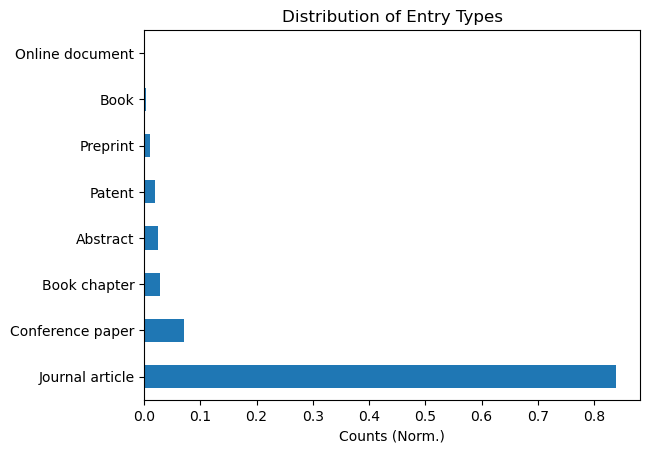

In [23]:
papers_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

It looks like over 80% of the entries are with non-null types are categorized as `Journal Article`. Let's isolate the data set to only have journal articles.

In [24]:
idx = papers_df[papers_df['Type'] != 'Journal article'].index
papers_df = papers_df.drop(idx).reset_index(drop = 'True')

Let's check the amount of remaining entires.

In [25]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 24880 entires remaining in the papers_df


We still have over 20,000 entries which is a healthy amount of entries.

Let's look at the distribution of remaining null values.

In [26]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Year              0.000482
Source            0.000040
Cites             0.000000
Authors           0.000000
Title             0.000000
GSRank            0.000000
Type              0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's check the null value distribution.

In [27]:
papers_df.isna().sum()

Cites              0
Authors            0
Title              0
Year              12
Source             1
GSRank             0
Type               0
ECC                0
CitesPerYear       0
CitesPerAuthor     0
AuthorCount        0
query_id           0
dtype: int64

There are still null values in the `Year` and `Source` column, though they contain about 0.1% and 0.005% of the entries, respectively. Based on previous analysis of entires with null values, these entries are likely miscellaneous entry types that were inccorrectly categorized as journal articles, conference papers or books. Therefore, let's remove those entries with null values for `Year`.

In [28]:
papers_df = papers_df.dropna(subset = ['Year', 'Source']).reset_index(drop = 'True')

In [29]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 24867 entires remaining in the papers_df


We still have a healthy number of entries at over 24,000. Let's check to see if there are any remaining null values.

In [30]:
papers_df.isna().sum()

Cites             0
Authors           0
Title             0
Year              0
Source            0
GSRank            0
Type              0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

Hurray! There are zero remaining null values for `papers_df`. Let's save this version of the data set into a pickle.

In [31]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part2.pkl")

### Conclusion

We successfully removed all the null values in the `papers_df` to create a data frame of *publication* entires. Though a handful of individual cases accounted for about 30 entries will null values in the `Source` column, most of the null values were removed by deleting duplicated entires for `Title`, only including entires with `Types` values `Journal article`, `Conference paper` and `Book`, and removing columns that had over 99% of the entires as null, and removing columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry.

## Part 3: Assigning Appropriate Data Types to `papers_df`

Let's look at the data types assigned to the columns in `papers_df` and see if any can be changed to better reflect the data in the column.

In [32]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int64  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  float64
 4   Source          24867 non-null  object 
 5   GSRank          24867 non-null  int64  
 6   Type            24867 non-null  object 
 7   ECC             24867 non-null  int64  
 8   CitesPerYear    24867 non-null  float64
 9   CitesPerAuthor  24867 non-null  int64  
 10  AuthorCount     24867 non-null  int64  
 11  query_id        24867 non-null  float64
dtypes: float64(3), int64(5), object(4)
memory usage: 2.3+ MB


The two most obvious columns where the data type can be changed is `Year` thats currently set to a non-numeric data type and `query_id` which is set to a `float` data type. Let's first change `Year` to a numeric data type `int16` since the year should only have 4 digits. 

In [33]:
papers_df['Year'] = papers_df['Year'].astype('int16')

In [34]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int64  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   GSRank          24867 non-null  int64  
 6   Type            24867 non-null  object 
 7   ECC             24867 non-null  int64  
 8   CitesPerYear    24867 non-null  float64
 9   CitesPerAuthor  24867 non-null  int64  
 10  AuthorCount     24867 non-null  int64  
 11  query_id        24867 non-null  float64
dtypes: float64(2), int16(1), int64(5), object(4)
memory usage: 2.1+ MB


Next, let's determine the appropriate integer type for the values in the `query_id` column by determining the maximum value.

In [35]:
print('The max value in the query_id column is {}'.format(papers_df['query_id'].max()))

The max value in the query_id column is 615.0


Since the max value in `query_id` is 615, let's change the data type to `int16`.

In [36]:
papers_df['query_id'] = papers_df['query_id'].astype('int16')

In [37]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int64  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   GSRank          24867 non-null  int64  
 6   Type            24867 non-null  object 
 7   ECC             24867 non-null  int64  
 8   CitesPerYear    24867 non-null  float64
 9   CitesPerAuthor  24867 non-null  int64  
 10  AuthorCount     24867 non-null  int64  
 11  query_id        24867 non-null  int16  
dtypes: float64(1), int16(2), int64(5), object(4)
memory usage: 2.0+ MB


All other columns look fine for now, though data types can always be changed later if needed. Let's save this state of the `papers_df` as a pickle.

In [38]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part3.pkl")

## Part 4 Preliminary Author Name Cleaning

In [39]:
papers_df['Authors'] = papers_df['Authors'].str.strip()
papers_df['Authors'] = papers_df['Authors'].str.rsplit(',')

In [40]:
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df['Authors'].values])
display(auth_df)

,0,1,2,3,4,5,6,7,8,9,10,11
0,D Shi,V Adinolfi,R Comin,M Yuan,E Alarousu,A Buin,Y Chen,...,None,None,None,None
1,K Lin,J Xing,LN Quan,FPG de Arquer,X Gong,J Lu,L Xie,W Zhao,...,None,None,None
2,SA McDonald,G Konstantatos,S Zhang,PW Cyr,EJD Klem,L Levina,...,None,None,None,None,None
3,H Tan,A Jain,O Voznyy,X Lan,FP García de Arquer,JZ Fan,...,None,None,None,None,None
4,G Konstantatos,I Howard,A Fischer,S Hoogland,J Clifford,E Klem,...,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
24862,Y Shin,S Cho,S Han,GY Jung,None,None,None,None,None,None,None,None
24863,C Liu,Y Yang,K Rakstys,A Mahata,M Franckevicius,E Mosconi,...,None,None,None,None,None
24864,S Driukas,D Rutkauskas,M Franckevičius,J Chmeliov,V Gulbinas,None,None,None,None,None,None,None
24865,M Faizan,KC Bhamu,G Murtaza,X He,N Kulhari,MM AL‐Anazy,...,None,None,None,None,None


In [41]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

In [42]:
display(auth_df)

,first_auth,second_auth,third_auth
0,D Shi,V Adinolfi,R Comin
1,K Lin,J Xing,LN Quan
2,SA McDonald,G Konstantatos,S Zhang
3,H Tan,A Jain,O Voznyy
4,G Konstantatos,I Howard,A Fischer
...,...,...,...
24862,Y Shin,S Cho,S Han
24863,C Liu,Y Yang,K Rakstys
24864,S Driukas,D Rutkauskas,M Franckevičius
24865,M Faizan,KC Bhamu,G Murtaza


Let's append this data frame to `papers_df` and drop the `Authors` column.

In [43]:
papers_df = pd.concat([auth_df, papers_df.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df` let's save it as a pickle.`

In [44]:
papers_df.sample(5)

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
606,EH Sargent,None,None,13,Size-tunable infrared (1000–1600 nm) electrolu...,2004,Journal of Modern Optics 51 (16-18),667,Journal article,13,0.68,13,1,0
12584,AD Ortiz,B Arnold,M Bumstead,2,Steric self-assembly of laterally confined org...,2014,Physical Chemistry Chemical Physics,61,Journal article,2,0.22,1,4,75
10905,A S. de León,M de la Mata,IR Sanchez-Alarcon,2,Self-Assembly of CsPbBr 3 Perovskites in Micro...,2022,ACS applied materials &interfaces,65,Journal article,2,2.00,0,5,55
19902,K Kholikov,D Seyitliyev,D Biechele-Speziale,0,Graphene quantum dot synthesis using nanosecon...,2016,Bulletin of the American Physical Society,37,Journal article,0,0.00,0,5,237
12631,R Hayakawa,A Turak,XN Zhang,16,Strain-effect for controlled growth mode and w...,2010,The Journal of chemical physics,31,Journal article,16,1.23,2,7,76


In [45]:
papers_df.to_pickle('2023-03-24_NB1_papers_df_part4.pkl')

In [46]:
import re

def edit_names(name):
    
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[\(\)-\.,=]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    return [edit_names(i) for i in row]

def edit_query_names(row):
    split_col = [i.strip() for i in row['Query'].rsplit(' - ')]
    name = split_col[0]
    ret_val = edit_names(name)
    return ret_val

In [47]:
query_df = query_df.assign(query_author = query_df.apply(edit_query_names, axis = 1))

In [48]:
query_df.sample(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA,query_author
397,397,Dr. Muhammad Junaid - Assistant Professor of P...,Google Scholar Profile,18,309,7,44.14,17.17,47.85,2.77,...,1,2016,2022,309,16,14,10,0,6,muhammad junaid
532,532,Adrián Francisco-López - PostDoc at ICMAB-CSIC...,Google Scholar Profile,9,160,5,32.00,17.78,26.00,2.29,...,2,2018,2021,160,8,7,4,0,4,adrin franciscolpez
349,349,"Saidatul Nur Aisyahtun - Student, UTeM",Google Scholar Profile,23,46,12,3.83,2.00,11.21,5.49,...,0,2011,2020,46,3,0,0,0,1,saidatul nur aisyahtun


In [49]:
result = query_df['query_author'].value_counts().sum() == query_df['Query'].value_counts().sum()
print('Are the number of unqiue Queries maintained?\t', result)

Are the number of unqiue Queries maintained?	 True


In [50]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']] = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

In [51]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(3)

,first_auth,second_auth,third_auth
13587,x li,hs xu,k leng
8087,g matula,t jardiel,b levenfeld
24422,i grinberg,dv west,m torres


In [55]:
idx = papers_df[papers_df['third_auth'].isna()].index
papers_df = papers_df.drop(idx)

In [56]:
uni_auth = np.unique(np.concatenate(np.asarray(papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']])))

In [57]:
pd.Series(uni_auth).value_counts().sort_values()

a a petrov       1
a alfonsov       1
a alfawaz        1
a agresti        1
a abascalsaiz    1
                ..
zv popovi        1
zv marinkovi     1
zt deng          1
zx shen          1
zz ma            1
Length: 17737, dtype: int64

In [ ]:
papers_df.isna().sum()

In [ ]:
papers_df.isna().sum()

Make a `join_df`

In [58]:
join_df = pd.merge(left = papers_df, right = query_df, left_on = 'query_id', right_on = 'id')

In [59]:
result = papers_df.shape[0] == join_df.shape[0]
print('Are the number of rows maintained?\t', result)

Are the number of rows maintained?	 True


In [60]:
subjoin_df = join_df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'query_author']]

In [61]:
subjoin_df = subjoin_df.reset_index(level=0)

In [62]:
subjoin_df.to_pickle('2023-03-24_NB1_subjoin_df.part4.pkl')

## Conclusion

We now have more accurate data types for the `papers_df` that will assist in performing exploratory data analysis and preventing memory overuse.

---